# Regression Algorithms Demonstration

This notebook demonstrates various regression algorithms using the Diabetes dataset.


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device selection
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Dictionary to store results for the final comparison
results = {}


Using device: cpu


Number of training samples: 353
Number of test samples: 89
Number of features: 10
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target name: disease_progression


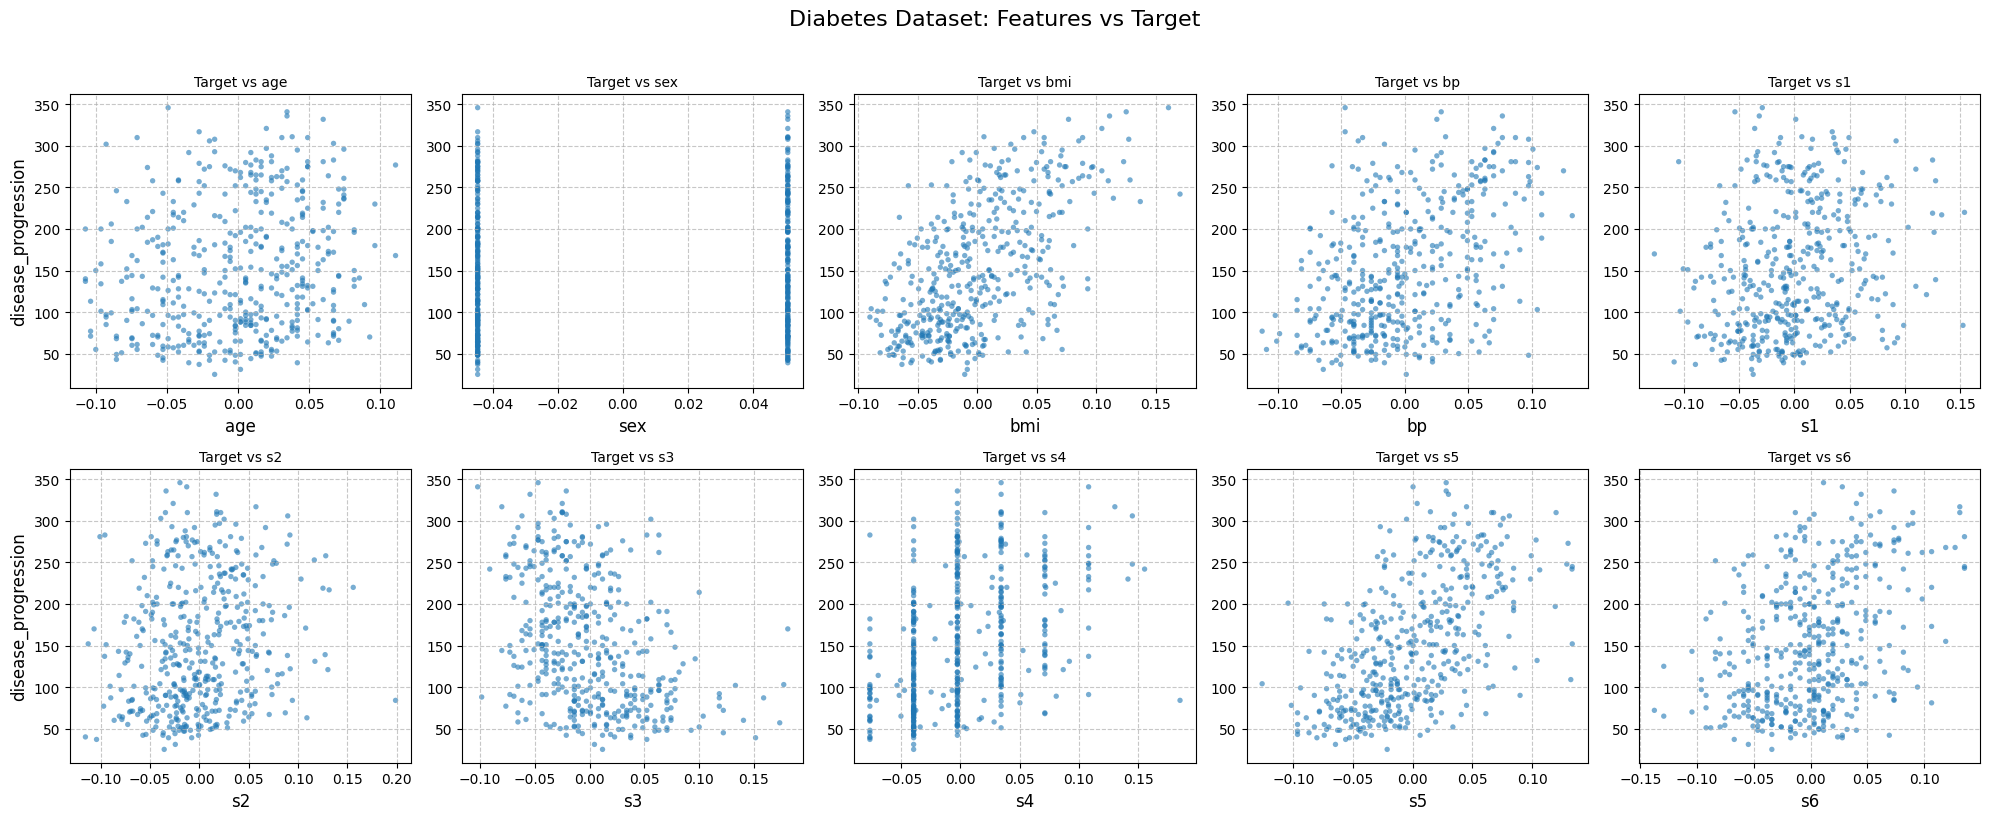

In [2]:
from datasets import load_dataset, get_feature_names, get_target_name, visualize_dataset

X_train, X_test, y_train, y_test = load_dataset(test_size=0.2, normalize=True, random_state=42)

print(f"Number of training samples: {X_train.shape[0]}")
print(f"Number of test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Feature names: {get_feature_names()}")
print(f"Target name: {get_target_name()}")

visualize_dataset()


In [3]:
from algorithm import (
    LinearRegression,
    PolynomialRegression,
    SGDRegression,
    DecisionTreeRegression,
    RandomForestRegression,
    KNNRegression,
    SupportVectorRegression,
    NeuralNetworkRegression,
    XGBoostRegression
)


/home/rabbi/Desktop/Regression_Project/algorithm.py:56: SyntaxWarning: invalid escape sequence '\h'
  """
/home/rabbi/Desktop/Regression_Project/algorithm.py:99: SyntaxWarning: invalid escape sequence '\e'
  """
/home/rabbi/Desktop/Regression_Project/algorithm.py:152: SyntaxWarning: invalid escape sequence '\h'
  """
/home/rabbi/Desktop/Regression_Project/algorithm.py:185: SyntaxWarning: invalid escape sequence '\l'
  """
/home/rabbi/Desktop/Regression_Project/algorithm.py:282: SyntaxWarning: invalid escape sequence '\h'
  """
/home/rabbi/Desktop/Regression_Project/algorithm.py:322: SyntaxWarning: invalid escape sequence '\h'
  """
/home/rabbi/Desktop/Regression_Project/algorithm.py:365: SyntaxWarning: invalid escape sequence '\m'
  """
/home/rabbi/Desktop/Regression_Project/algorithm.py:414: SyntaxWarning: invalid escape sequence '\h'
  """
/home/rabbi/Desktop/Regression_Project/algorithm.py:463: SyntaxWarning: invalid escape sequence '\c'
  """
/home/rabbi/Desktop/Regression_Project/

# Linear Regression

Linear Regression models the relationship between the features and the target variable by fitting a linear equation to the observed data.


In [4]:
model = LinearRegression(device=device)


In [5]:
start_time = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Training Time: {train_time:.4f} seconds")


Training Time: 0.7206 seconds


In [6]:
start_time = time.time()
pred = model.predict(X_test)
pred_time = time.time() - start_time
print(f"Prediction Time: {pred_time:.4f} seconds")


Prediction Time: 0.0010 seconds


In [7]:
# Convert predictions to cpu/numpy for evaluation
y_true = y_test.cpu().numpy()
y_pred = pred.cpu().numpy()

# Ensure same shape
if y_pred.ndim == 1:
    y_pred = y_pred.reshape(-1, 1)

mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_true - y_pred))

# R2 Score calculation
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

results["Linear Regression"] = {
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "R² Score": r2,
    "Training Time": train_time,
    "Prediction Time": pred_time
}


MSE: 3352.8599
RMSE: 57.9039
MAE: 47.4187
R² Score: 0.4785


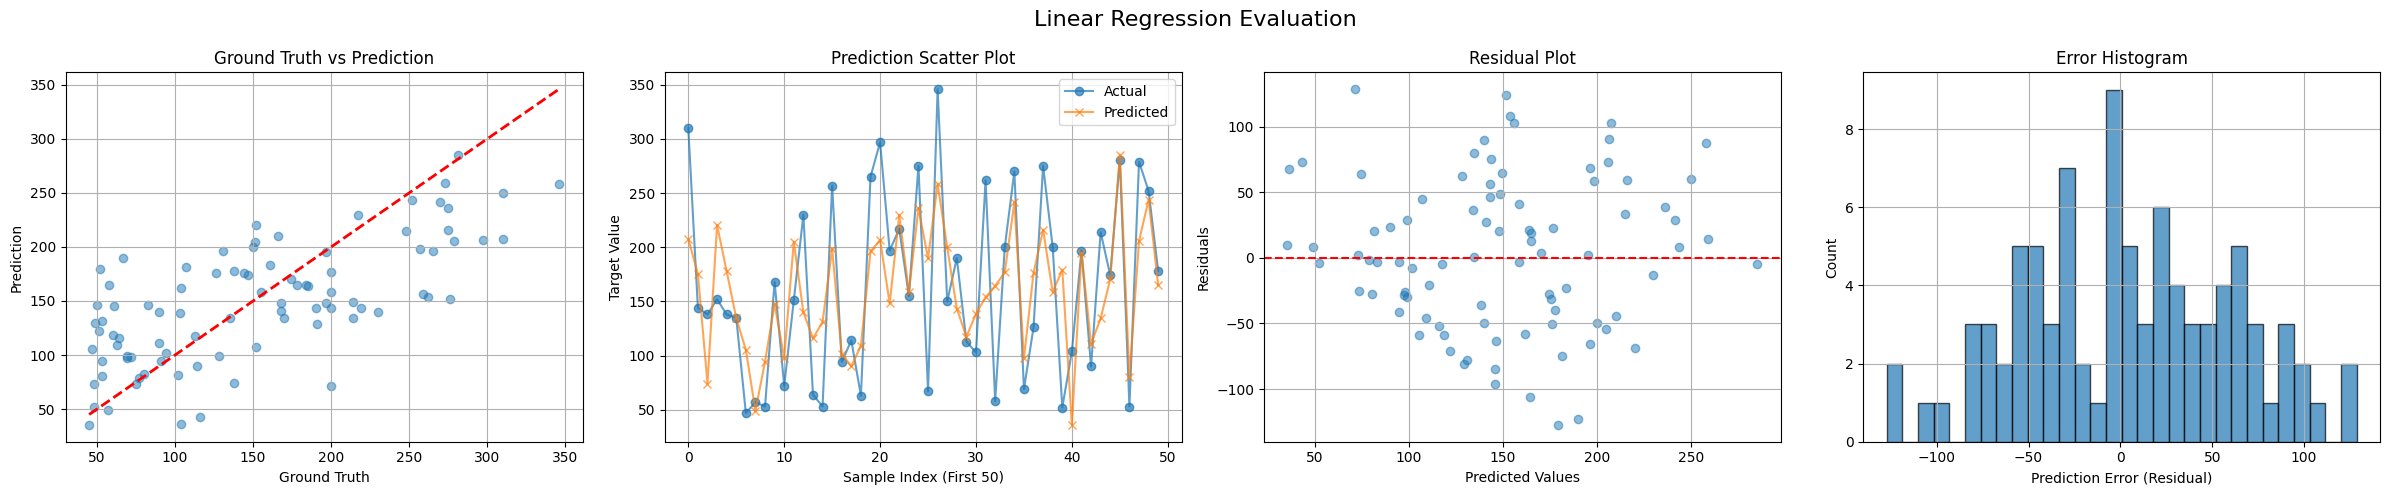

In [8]:
# Visualization for Linear Regression
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("Linear Regression Evaluation", fontsize=16)

# 1. Ground Truth vs Prediction
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].scatter(y_true, y_pred, alpha=0.5)
axes[0].set_xlabel("Ground Truth")
axes[0].set_ylabel("Prediction")
axes[0].set_title("Ground Truth vs Prediction")
axes[0].grid(True)

# 2. Prediction Scatter Plot (Index vs Value)
axes[1].plot(y_true[:50], label='Actual', marker='o', alpha=0.7)
axes[1].plot(y_pred[:50], label='Predicted', marker='x', alpha=0.7)
axes[1].set_xlabel("Sample Index (First 50)")
axes[1].set_ylabel("Target Value")
axes[1].set_title("Prediction Scatter Plot")
axes[1].legend()
axes[1].grid(True)

# 3. Residual Plot
residuals = y_true - y_pred
axes[2].scatter(y_pred, residuals, alpha=0.5)
axes[2].axhline(0, color='r', linestyle='--')
axes[2].set_xlabel("Predicted Values")
axes[2].set_ylabel("Residuals")
axes[2].set_title("Residual Plot")
axes[2].grid(True)

# 4. Error Histogram
axes[3].hist(residuals, bins=30, edgecolor='k', alpha=0.7)
axes[3].set_xlabel("Prediction Error (Residual)")
axes[3].set_ylabel("Count")
axes[3].set_title("Error Histogram")
axes[3].grid(True)

plt.tight_layout()
plt.show()


# Polynomial Regression

Polynomial Regression extends linear regression by adding polynomial features, capturing non-linear relationships.


In [9]:
model = PolynomialRegression(degree=2, device=device)


In [10]:
start_time = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Training Time: {train_time:.4f} seconds")


Training Time: 0.0323 seconds


In [11]:
start_time = time.time()
pred = model.predict(X_test)
pred_time = time.time() - start_time
print(f"Prediction Time: {pred_time:.4f} seconds")


Prediction Time: 0.0020 seconds


In [12]:
# Convert predictions to cpu/numpy for evaluation
y_true = y_test.cpu().numpy()
y_pred = pred.cpu().numpy()

# Ensure same shape
if y_pred.ndim == 1:
    y_pred = y_pred.reshape(-1, 1)

mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_true - y_pred))

# R2 Score calculation
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

results["Polynomial Regression"] = {
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "R² Score": r2,
    "Training Time": train_time,
    "Prediction Time": pred_time
}


MSE: 3292.5833
RMSE: 57.3810
MAE: 47.2590
R² Score: 0.4878


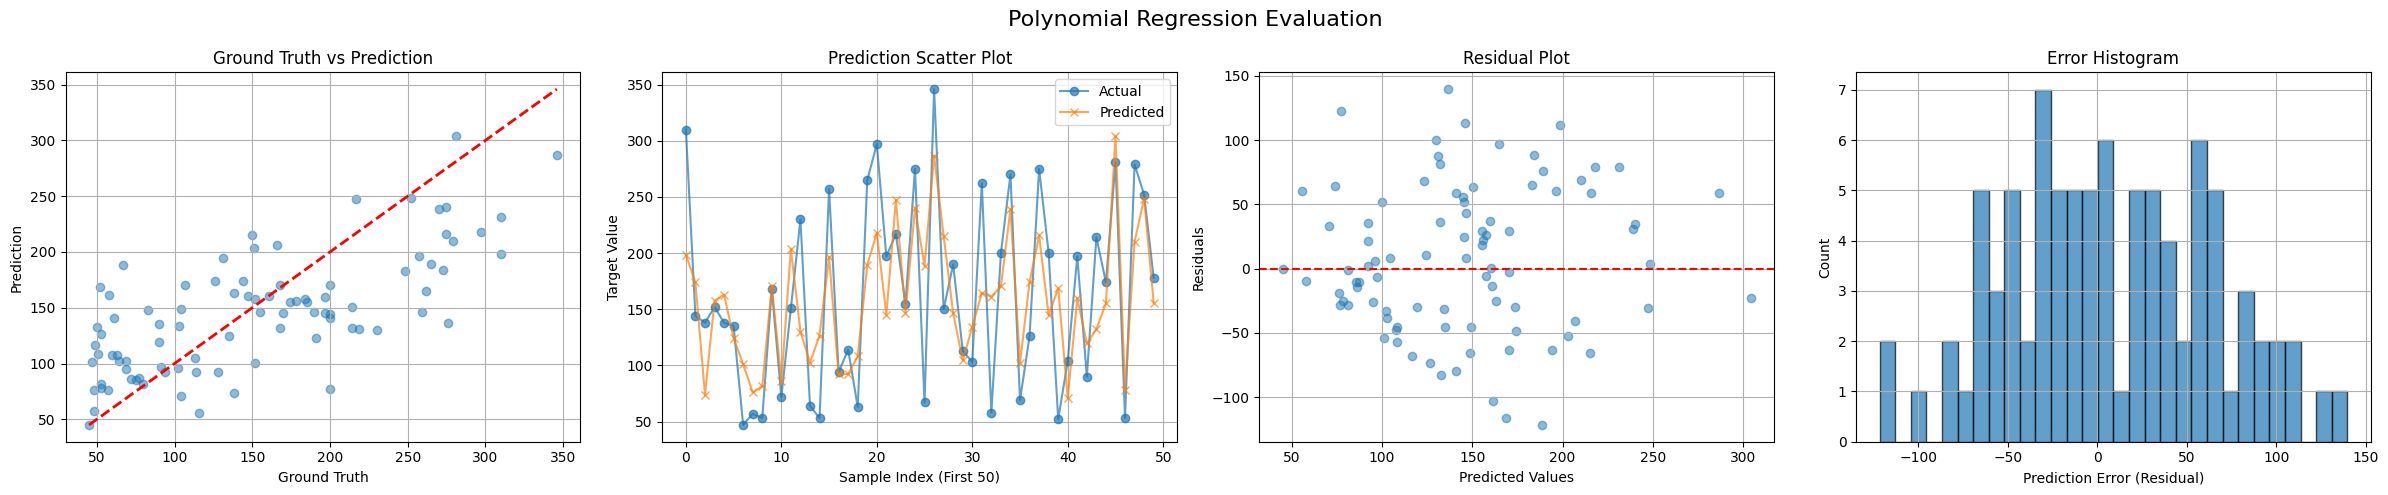

In [13]:
# Visualization for Polynomial Regression
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("Polynomial Regression Evaluation", fontsize=16)

# 1. Ground Truth vs Prediction
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].scatter(y_true, y_pred, alpha=0.5)
axes[0].set_xlabel("Ground Truth")
axes[0].set_ylabel("Prediction")
axes[0].set_title("Ground Truth vs Prediction")
axes[0].grid(True)

# 2. Prediction Scatter Plot (Index vs Value)
axes[1].plot(y_true[:50], label='Actual', marker='o', alpha=0.7)
axes[1].plot(y_pred[:50], label='Predicted', marker='x', alpha=0.7)
axes[1].set_xlabel("Sample Index (First 50)")
axes[1].set_ylabel("Target Value")
axes[1].set_title("Prediction Scatter Plot")
axes[1].legend()
axes[1].grid(True)

# 3. Residual Plot
residuals = y_true - y_pred
axes[2].scatter(y_pred, residuals, alpha=0.5)
axes[2].axhline(0, color='r', linestyle='--')
axes[2].set_xlabel("Predicted Values")
axes[2].set_ylabel("Residuals")
axes[2].set_title("Residual Plot")
axes[2].grid(True)

# 4. Error Histogram
axes[3].hist(residuals, bins=30, edgecolor='k', alpha=0.7)
axes[3].set_xlabel("Prediction Error (Residual)")
axes[3].set_ylabel("Count")
axes[3].set_title("Error Histogram")
axes[3].grid(True)

plt.tight_layout()
plt.show()


# SGD Regression

SGD Regression trains a linear model using Stochastic Gradient Descent, optimizing parameters iteratively.


In [14]:
model = SGDRegression(lr=0.01, epochs=1000, device=device)


In [15]:
start_time = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Training Time: {train_time:.4f} seconds")


Training Time: 9.6844 seconds


In [16]:
start_time = time.time()
pred = model.predict(X_test)
pred_time = time.time() - start_time
print(f"Prediction Time: {pred_time:.4f} seconds")


Prediction Time: 0.0005 seconds


In [17]:
# Convert predictions to cpu/numpy for evaluation
y_true = y_test.cpu().numpy()
y_pred = pred.cpu().numpy()

# Ensure same shape
if y_pred.ndim == 1:
    y_pred = y_pred.reshape(-1, 1)

mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_true - y_pred))

# R2 Score calculation
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

results["SGD Regression"] = {
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "R² Score": r2,
    "Training Time": train_time,
    "Prediction Time": pred_time
}


MSE: 3255.3079
RMSE: 57.0553
MAE: 46.8895
R² Score: 0.4936


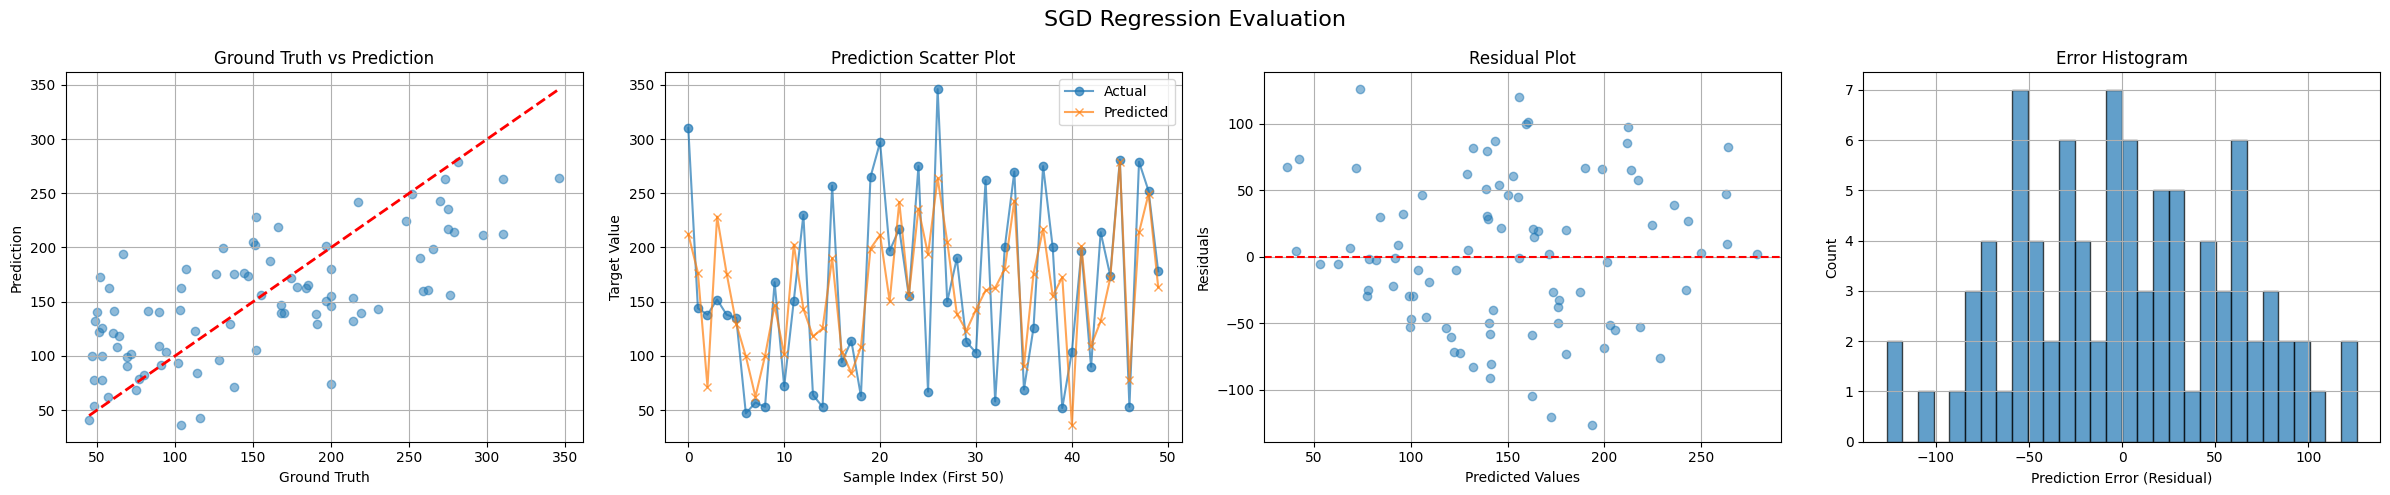

In [18]:
# Visualization for SGD Regression
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("SGD Regression Evaluation", fontsize=16)

# 1. Ground Truth vs Prediction
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].scatter(y_true, y_pred, alpha=0.5)
axes[0].set_xlabel("Ground Truth")
axes[0].set_ylabel("Prediction")
axes[0].set_title("Ground Truth vs Prediction")
axes[0].grid(True)

# 2. Prediction Scatter Plot (Index vs Value)
axes[1].plot(y_true[:50], label='Actual', marker='o', alpha=0.7)
axes[1].plot(y_pred[:50], label='Predicted', marker='x', alpha=0.7)
axes[1].set_xlabel("Sample Index (First 50)")
axes[1].set_ylabel("Target Value")
axes[1].set_title("Prediction Scatter Plot")
axes[1].legend()
axes[1].grid(True)

# 3. Residual Plot
residuals = y_true - y_pred
axes[2].scatter(y_pred, residuals, alpha=0.5)
axes[2].axhline(0, color='r', linestyle='--')
axes[2].set_xlabel("Predicted Values")
axes[2].set_ylabel("Residuals")
axes[2].set_title("Residual Plot")
axes[2].grid(True)

# 4. Error Histogram
axes[3].hist(residuals, bins=30, edgecolor='k', alpha=0.7)
axes[3].set_xlabel("Prediction Error (Residual)")
axes[3].set_ylabel("Count")
axes[3].set_title("Error Histogram")
axes[3].grid(True)

plt.tight_layout()
plt.show()


# Decision Tree Regression

Decision Tree Regression splits the data space into distinct regions to predict the target variable based on simple rules.


In [19]:
model = DecisionTreeRegression(max_depth=5, device=device)


In [20]:
start_time = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Training Time: {train_time:.4f} seconds")


Training Time: 2.0469 seconds


In [21]:
start_time = time.time()
pred = model.predict(X_test)
pred_time = time.time() - start_time
print(f"Prediction Time: {pred_time:.4f} seconds")


Prediction Time: 0.0153 seconds


In [22]:
# Convert predictions to cpu/numpy for evaluation
y_true = y_test.cpu().numpy()
y_pred = pred.cpu().numpy()

# Ensure same shape
if y_pred.ndim == 1:
    y_pred = y_pred.reshape(-1, 1)

mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_true - y_pred))

# R2 Score calculation
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

results["Decision Tree Regression"] = {
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "R² Score": r2,
    "Training Time": train_time,
    "Prediction Time": pred_time
}


MSE: 5719.4858
RMSE: 75.6273
MAE: 60.8734
R² Score: 0.1103


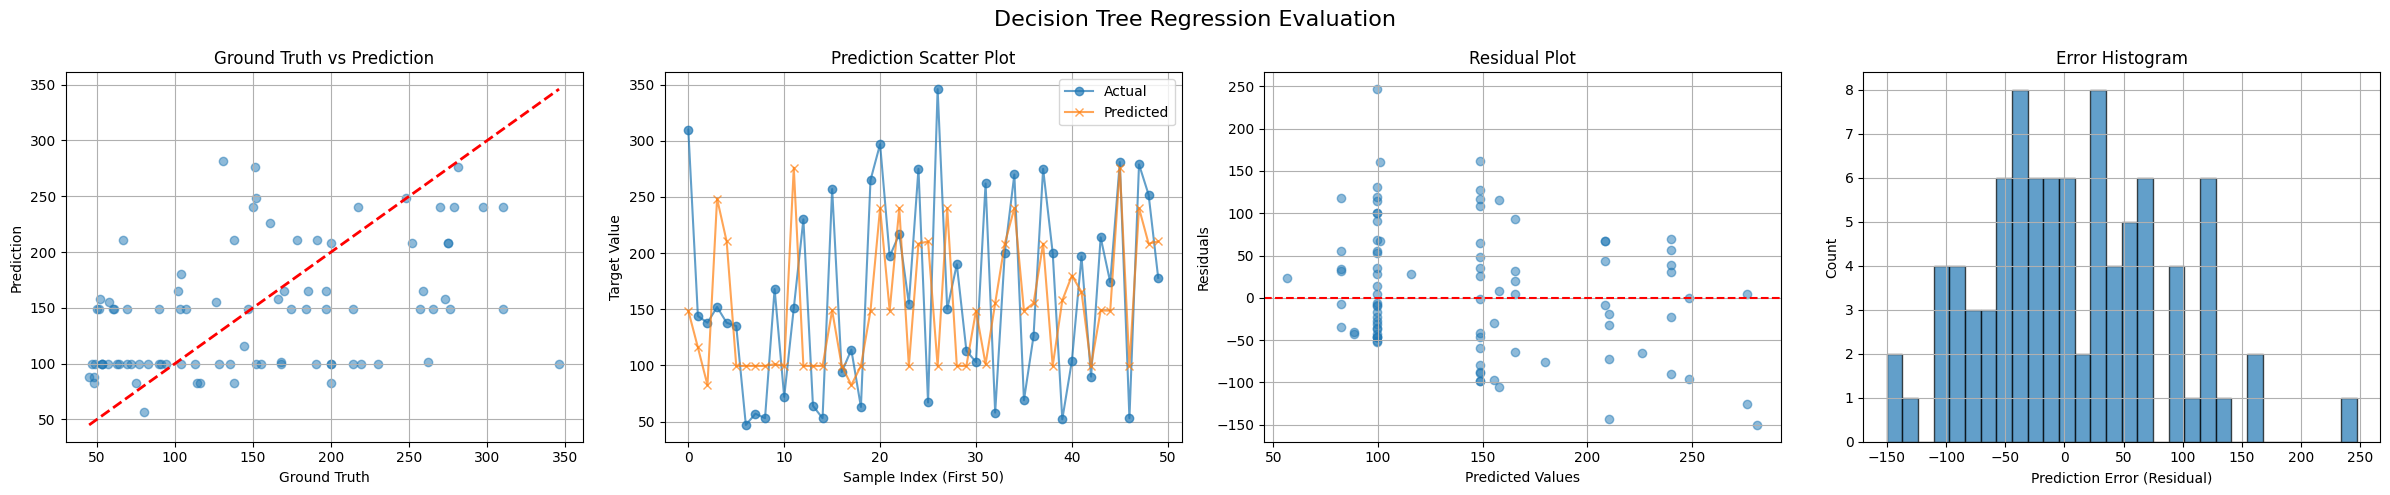

In [23]:
# Visualization for Decision Tree Regression
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("Decision Tree Regression Evaluation", fontsize=16)

# 1. Ground Truth vs Prediction
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].scatter(y_true, y_pred, alpha=0.5)
axes[0].set_xlabel("Ground Truth")
axes[0].set_ylabel("Prediction")
axes[0].set_title("Ground Truth vs Prediction")
axes[0].grid(True)

# 2. Prediction Scatter Plot (Index vs Value)
axes[1].plot(y_true[:50], label='Actual', marker='o', alpha=0.7)
axes[1].plot(y_pred[:50], label='Predicted', marker='x', alpha=0.7)
axes[1].set_xlabel("Sample Index (First 50)")
axes[1].set_ylabel("Target Value")
axes[1].set_title("Prediction Scatter Plot")
axes[1].legend()
axes[1].grid(True)

# 3. Residual Plot
residuals = y_true - y_pred
axes[2].scatter(y_pred, residuals, alpha=0.5)
axes[2].axhline(0, color='r', linestyle='--')
axes[2].set_xlabel("Predicted Values")
axes[2].set_ylabel("Residuals")
axes[2].set_title("Residual Plot")
axes[2].grid(True)

# 4. Error Histogram
axes[3].hist(residuals, bins=30, edgecolor='k', alpha=0.7)
axes[3].set_xlabel("Prediction Error (Residual)")
axes[3].set_ylabel("Count")
axes[3].set_title("Error Histogram")
axes[3].grid(True)

plt.tight_layout()
plt.show()


# Random Forest Regression

Random Forest Regression uses an ensemble of decision trees to improve predictive accuracy and control over-fitting.


In [24]:
model = RandomForestRegression(n_estimators=50, max_depth=5, device=device)


In [25]:
start_time = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Training Time: {train_time:.4f} seconds")


Training Time: 44.0894 seconds


In [26]:
start_time = time.time()
pred = model.predict(X_test)
pred_time = time.time() - start_time
print(f"Prediction Time: {pred_time:.4f} seconds")


Prediction Time: 0.1511 seconds


In [27]:
# Convert predictions to cpu/numpy for evaluation
y_true = y_test.cpu().numpy()
y_pred = pred.cpu().numpy()

# Ensure same shape
if y_pred.ndim == 1:
    y_pred = y_pred.reshape(-1, 1)

mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_true - y_pred))

# R2 Score calculation
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

results["Random Forest Regression"] = {
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "R² Score": r2,
    "Training Time": train_time,
    "Prediction Time": pred_time
}


MSE: 4199.5215
RMSE: 64.8037
MAE: 52.7177
R² Score: 0.3468


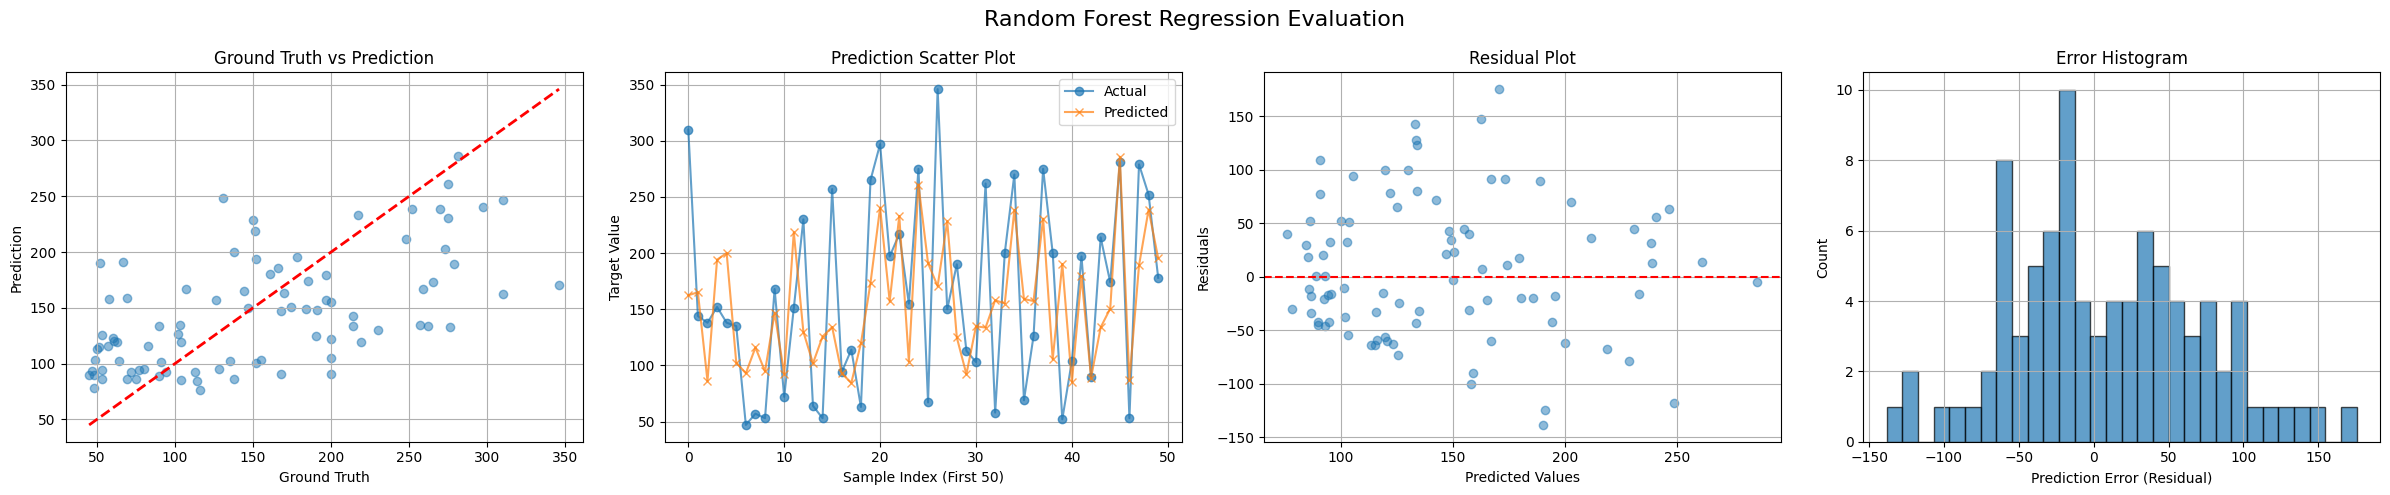

In [28]:
# Visualization for Random Forest Regression
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("Random Forest Regression Evaluation", fontsize=16)

# 1. Ground Truth vs Prediction
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].scatter(y_true, y_pred, alpha=0.5)
axes[0].set_xlabel("Ground Truth")
axes[0].set_ylabel("Prediction")
axes[0].set_title("Ground Truth vs Prediction")
axes[0].grid(True)

# 2. Prediction Scatter Plot (Index vs Value)
axes[1].plot(y_true[:50], label='Actual', marker='o', alpha=0.7)
axes[1].plot(y_pred[:50], label='Predicted', marker='x', alpha=0.7)
axes[1].set_xlabel("Sample Index (First 50)")
axes[1].set_ylabel("Target Value")
axes[1].set_title("Prediction Scatter Plot")
axes[1].legend()
axes[1].grid(True)

# 3. Residual Plot
residuals = y_true - y_pred
axes[2].scatter(y_pred, residuals, alpha=0.5)
axes[2].axhline(0, color='r', linestyle='--')
axes[2].set_xlabel("Predicted Values")
axes[2].set_ylabel("Residuals")
axes[2].set_title("Residual Plot")
axes[2].grid(True)

# 4. Error Histogram
axes[3].hist(residuals, bins=30, edgecolor='k', alpha=0.7)
axes[3].set_xlabel("Prediction Error (Residual)")
axes[3].set_ylabel("Count")
axes[3].set_title("Error Histogram")
axes[3].grid(True)

plt.tight_layout()
plt.show()


# KNN Regression

K-Nearest Neighbors (KNN) Regression predicts the target variable based on the average of its k nearest neighbors.


In [29]:
model = KNNRegression(k=5, device=device)


In [30]:
start_time = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Training Time: {train_time:.4f} seconds")


Training Time: 0.0006 seconds


In [31]:
start_time = time.time()
pred = model.predict(X_test)
pred_time = time.time() - start_time
print(f"Prediction Time: {pred_time:.4f} seconds")


Prediction Time: 0.1781 seconds


In [32]:
# Convert predictions to cpu/numpy for evaluation
y_true = y_test.cpu().numpy()
y_pred = pred.cpu().numpy()

# Ensure same shape
if y_pred.ndim == 1:
    y_pred = y_pred.reshape(-1, 1)

mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_true - y_pred))

# R2 Score calculation
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

results["KNN Regression"] = {
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "R² Score": r2,
    "Training Time": train_time,
    "Prediction Time": pred_time
}


MSE: 4282.0190
RMSE: 65.4371
MAE: 51.2517
R² Score: 0.3339


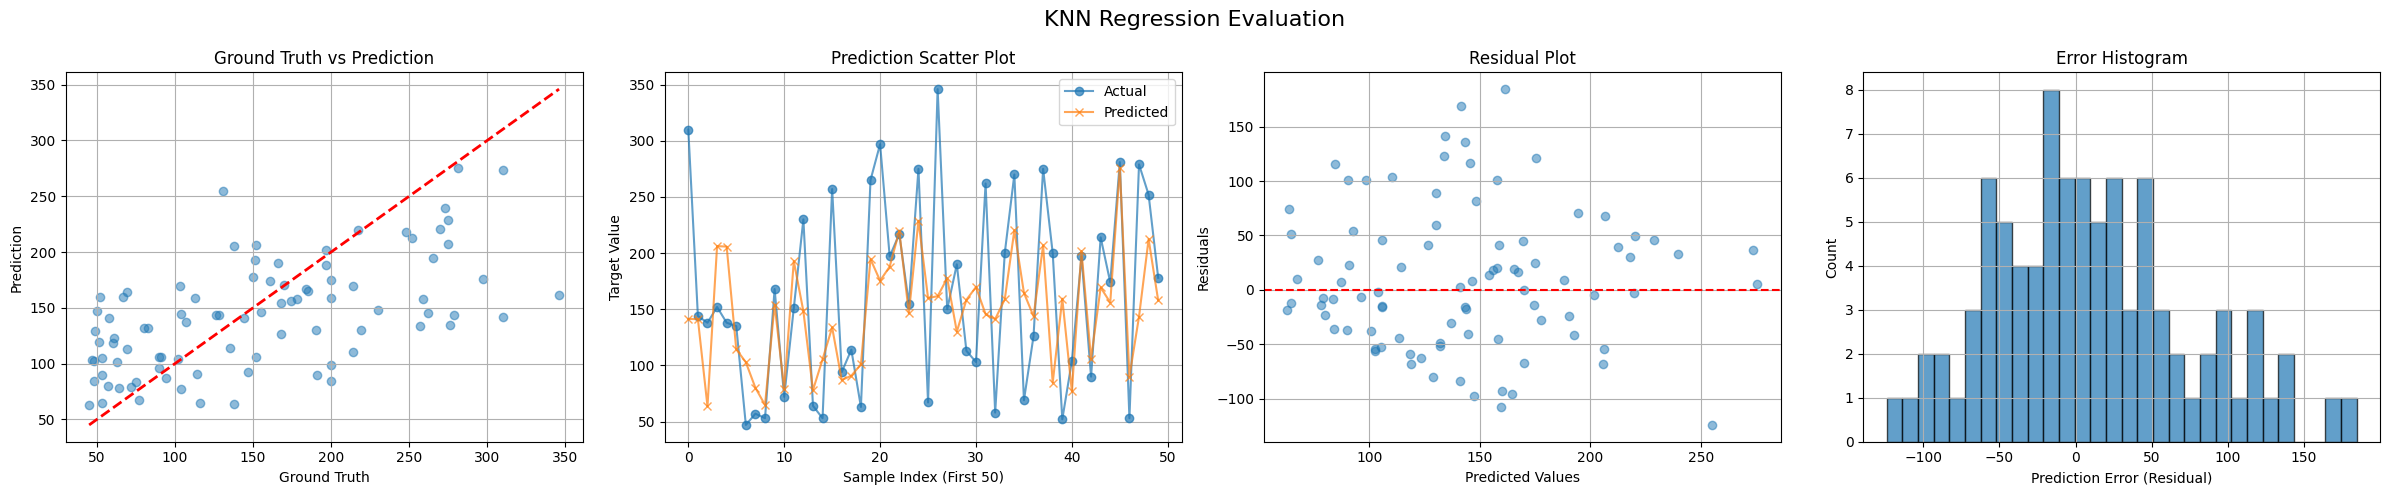

In [33]:
# Visualization for KNN Regression
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("KNN Regression Evaluation", fontsize=16)

# 1. Ground Truth vs Prediction
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].scatter(y_true, y_pred, alpha=0.5)
axes[0].set_xlabel("Ground Truth")
axes[0].set_ylabel("Prediction")
axes[0].set_title("Ground Truth vs Prediction")
axes[0].grid(True)

# 2. Prediction Scatter Plot (Index vs Value)
axes[1].plot(y_true[:50], label='Actual', marker='o', alpha=0.7)
axes[1].plot(y_pred[:50], label='Predicted', marker='x', alpha=0.7)
axes[1].set_xlabel("Sample Index (First 50)")
axes[1].set_ylabel("Target Value")
axes[1].set_title("Prediction Scatter Plot")
axes[1].legend()
axes[1].grid(True)

# 3. Residual Plot
residuals = y_true - y_pred
axes[2].scatter(y_pred, residuals, alpha=0.5)
axes[2].axhline(0, color='r', linestyle='--')
axes[2].set_xlabel("Predicted Values")
axes[2].set_ylabel("Residuals")
axes[2].set_title("Residual Plot")
axes[2].grid(True)

# 4. Error Histogram
axes[3].hist(residuals, bins=30, edgecolor='k', alpha=0.7)
axes[3].set_xlabel("Prediction Error (Residual)")
axes[3].set_ylabel("Count")
axes[3].set_title("Error Histogram")
axes[3].grid(True)

plt.tight_layout()
plt.show()


# Support Vector Regression

Support Vector Regression uses support vector machines to find a function that deviates from the target by at most epsilon.


In [34]:
model = SupportVectorRegression(epsilon=0.1, C=1.0, lr=0.01, epochs=1000, device=device)


In [35]:
start_time = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Training Time: {train_time:.4f} seconds")


Training Time: 0.9632 seconds


In [36]:
start_time = time.time()
pred = model.predict(X_test)
pred_time = time.time() - start_time
print(f"Prediction Time: {pred_time:.4f} seconds")


Prediction Time: 0.0004 seconds


In [37]:
# Convert predictions to cpu/numpy for evaluation
y_true = y_test.cpu().numpy()
y_pred = pred.cpu().numpy()

# Ensure same shape
if y_pred.ndim == 1:
    y_pred = y_pred.reshape(-1, 1)

mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_true - y_pred))

# R2 Score calculation
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

results["Support Vector Regression"] = {
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "R² Score": r2,
    "Training Time": train_time,
    "Prediction Time": pred_time
}


MSE: 26613.1816
RMSE: 163.1355
MAE: 142.0719
R² Score: -3.1397


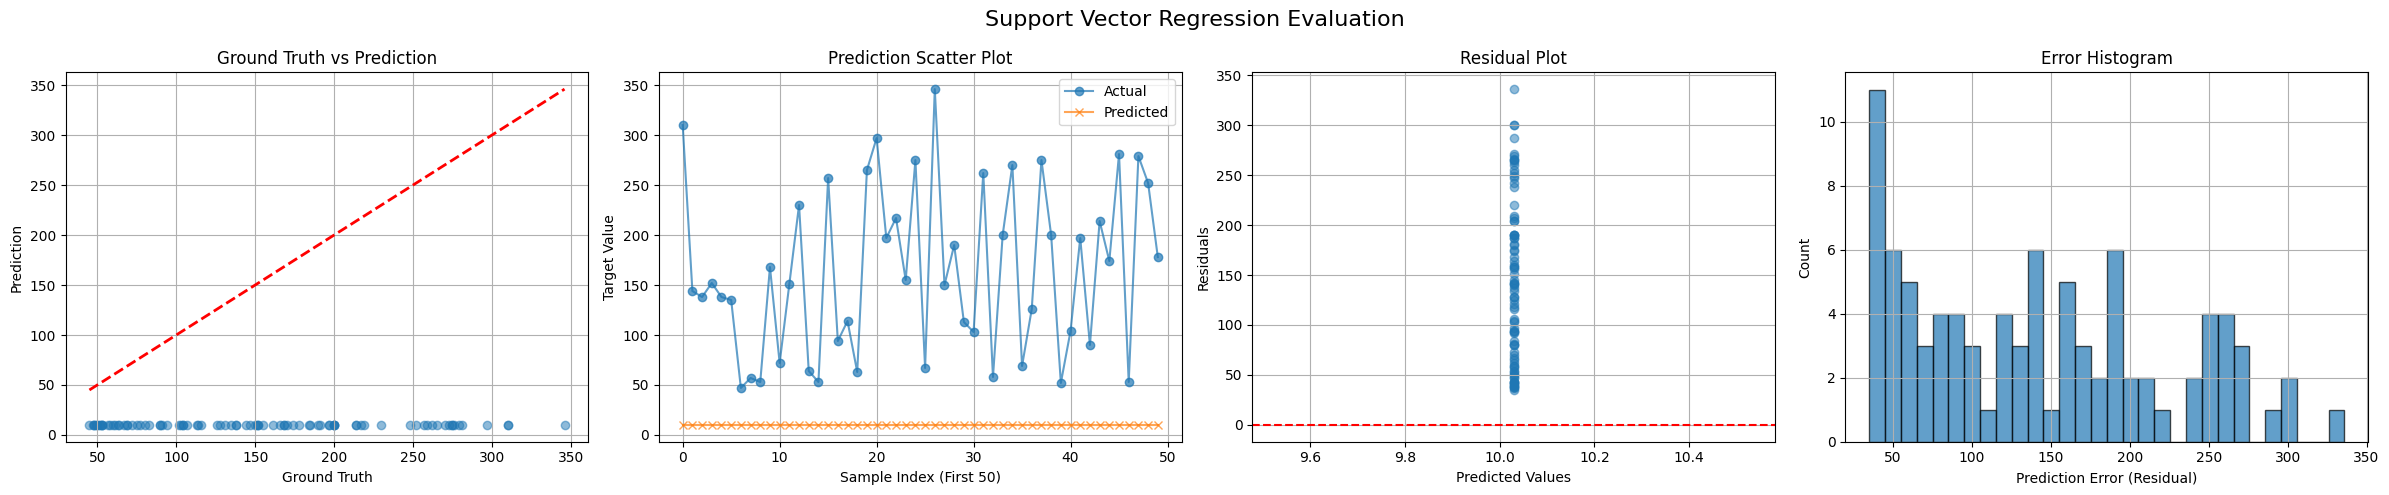

In [38]:
# Visualization for Support Vector Regression
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("Support Vector Regression Evaluation", fontsize=16)

# 1. Ground Truth vs Prediction
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].scatter(y_true, y_pred, alpha=0.5)
axes[0].set_xlabel("Ground Truth")
axes[0].set_ylabel("Prediction")
axes[0].set_title("Ground Truth vs Prediction")
axes[0].grid(True)

# 2. Prediction Scatter Plot (Index vs Value)
axes[1].plot(y_true[:50], label='Actual', marker='o', alpha=0.7)
axes[1].plot(y_pred[:50], label='Predicted', marker='x', alpha=0.7)
axes[1].set_xlabel("Sample Index (First 50)")
axes[1].set_ylabel("Target Value")
axes[1].set_title("Prediction Scatter Plot")
axes[1].legend()
axes[1].grid(True)

# 3. Residual Plot
residuals = y_true - y_pred
axes[2].scatter(y_pred, residuals, alpha=0.5)
axes[2].axhline(0, color='r', linestyle='--')
axes[2].set_xlabel("Predicted Values")
axes[2].set_ylabel("Residuals")
axes[2].set_title("Residual Plot")
axes[2].grid(True)

# 4. Error Histogram
axes[3].hist(residuals, bins=30, edgecolor='k', alpha=0.7)
axes[3].set_xlabel("Prediction Error (Residual)")
axes[3].set_ylabel("Count")
axes[3].set_title("Error Histogram")
axes[3].grid(True)

plt.tight_layout()
plt.show()


# Neural Network Regression

Neural Network Regression uses a multi-layer perceptron to learn non-linear relationships through hidden layers.


In [39]:
model = NeuralNetworkRegression(hidden_dim=64, lr=0.01, epochs=1000, device=device)


In [40]:
start_time = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Training Time: {train_time:.4f} seconds")


Training Time: 1.2255 seconds


In [41]:
start_time = time.time()
pred = model.predict(X_test)
pred_time = time.time() - start_time
print(f"Prediction Time: {pred_time:.4f} seconds")


Prediction Time: 0.0015 seconds


In [42]:
# Convert predictions to cpu/numpy for evaluation
y_true = y_test.cpu().numpy()
y_pred = pred.cpu().numpy()

# Ensure same shape
if y_pred.ndim == 1:
    y_pred = y_pred.reshape(-1, 1)

mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_true - y_pred))

# R2 Score calculation
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

results["Neural Network Regression"] = {
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "R² Score": r2,
    "Training Time": train_time,
    "Prediction Time": pred_time
}


MSE: 3833.5898
RMSE: 61.9160
MAE: 47.9694
R² Score: 0.4037


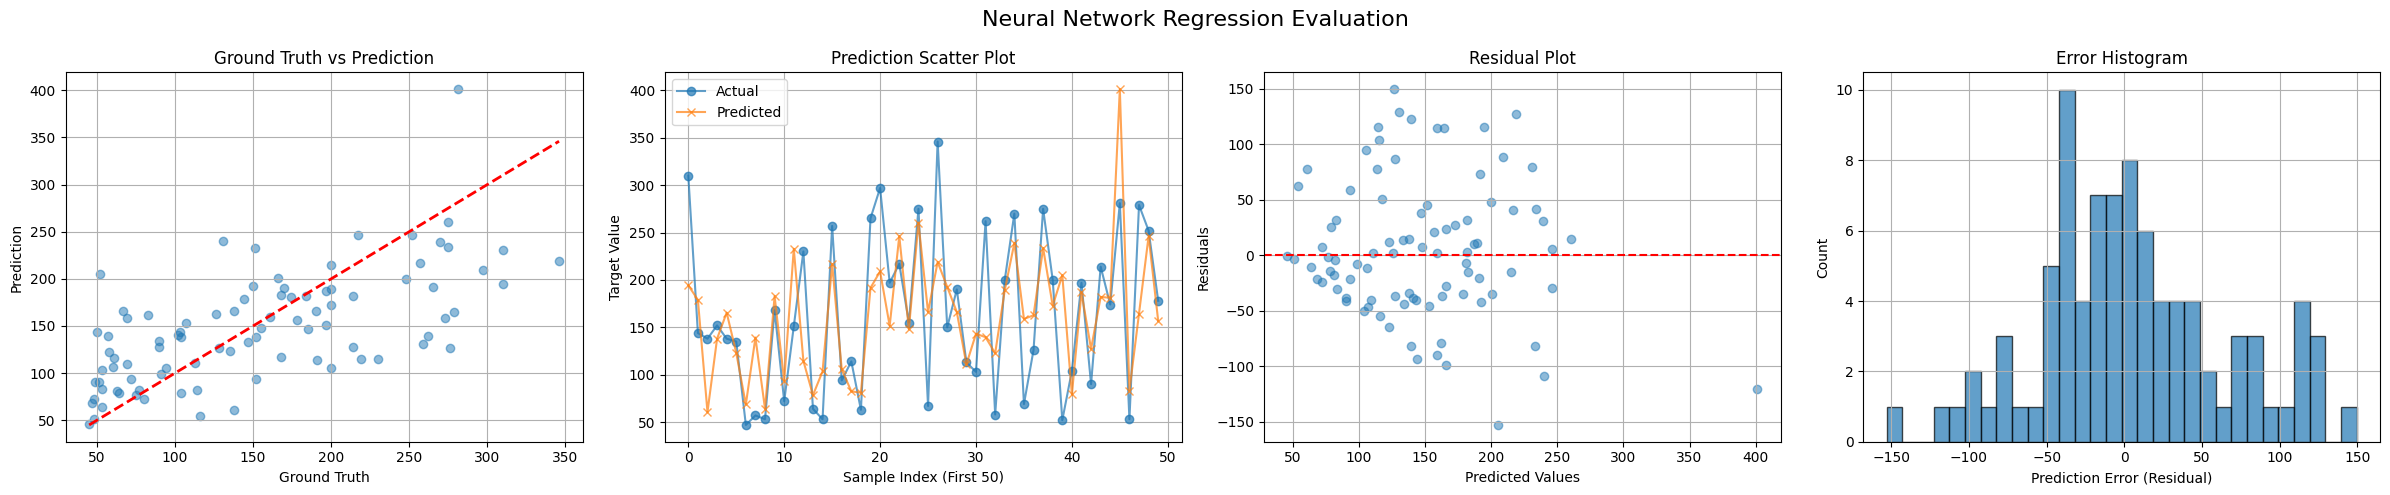

In [43]:
# Visualization for Neural Network Regression
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("Neural Network Regression Evaluation", fontsize=16)

# 1. Ground Truth vs Prediction
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].scatter(y_true, y_pred, alpha=0.5)
axes[0].set_xlabel("Ground Truth")
axes[0].set_ylabel("Prediction")
axes[0].set_title("Ground Truth vs Prediction")
axes[0].grid(True)

# 2. Prediction Scatter Plot (Index vs Value)
axes[1].plot(y_true[:50], label='Actual', marker='o', alpha=0.7)
axes[1].plot(y_pred[:50], label='Predicted', marker='x', alpha=0.7)
axes[1].set_xlabel("Sample Index (First 50)")
axes[1].set_ylabel("Target Value")
axes[1].set_title("Prediction Scatter Plot")
axes[1].legend()
axes[1].grid(True)

# 3. Residual Plot
residuals = y_true - y_pred
axes[2].scatter(y_pred, residuals, alpha=0.5)
axes[2].axhline(0, color='r', linestyle='--')
axes[2].set_xlabel("Predicted Values")
axes[2].set_ylabel("Residuals")
axes[2].set_title("Residual Plot")
axes[2].grid(True)

# 4. Error Histogram
axes[3].hist(residuals, bins=30, edgecolor='k', alpha=0.7)
axes[3].set_xlabel("Prediction Error (Residual)")
axes[3].set_ylabel("Count")
axes[3].set_title("Error Histogram")
axes[3].grid(True)

plt.tight_layout()
plt.show()


# XGBoost Regression

XGBoost Regression is a gradient boosting machine that builds additive models sequentially by fitting trees to residuals.


In [44]:
model = XGBoostRegression(n_estimators=50, learning_rate=0.1, max_depth=3, device=device)


In [45]:
start_time = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Training Time: {train_time:.4f} seconds")


Training Time: 24.1431 seconds


In [46]:
start_time = time.time()
pred = model.predict(X_test)
pred_time = time.time() - start_time
print(f"Prediction Time: {pred_time:.4f} seconds")


Prediction Time: 0.0978 seconds


In [47]:
# Convert predictions to cpu/numpy for evaluation
y_true = y_test.cpu().numpy()
y_pred = pred.cpu().numpy()

# Ensure same shape
if y_pred.ndim == 1:
    y_pred = y_pred.reshape(-1, 1)

mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_true - y_pred))

# R2 Score calculation
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

results["XGBoost Regression"] = {
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "R² Score": r2,
    "Training Time": train_time,
    "Prediction Time": pred_time
}


MSE: 4317.0215
RMSE: 65.7040
MAE: 53.6011
R² Score: 0.3285


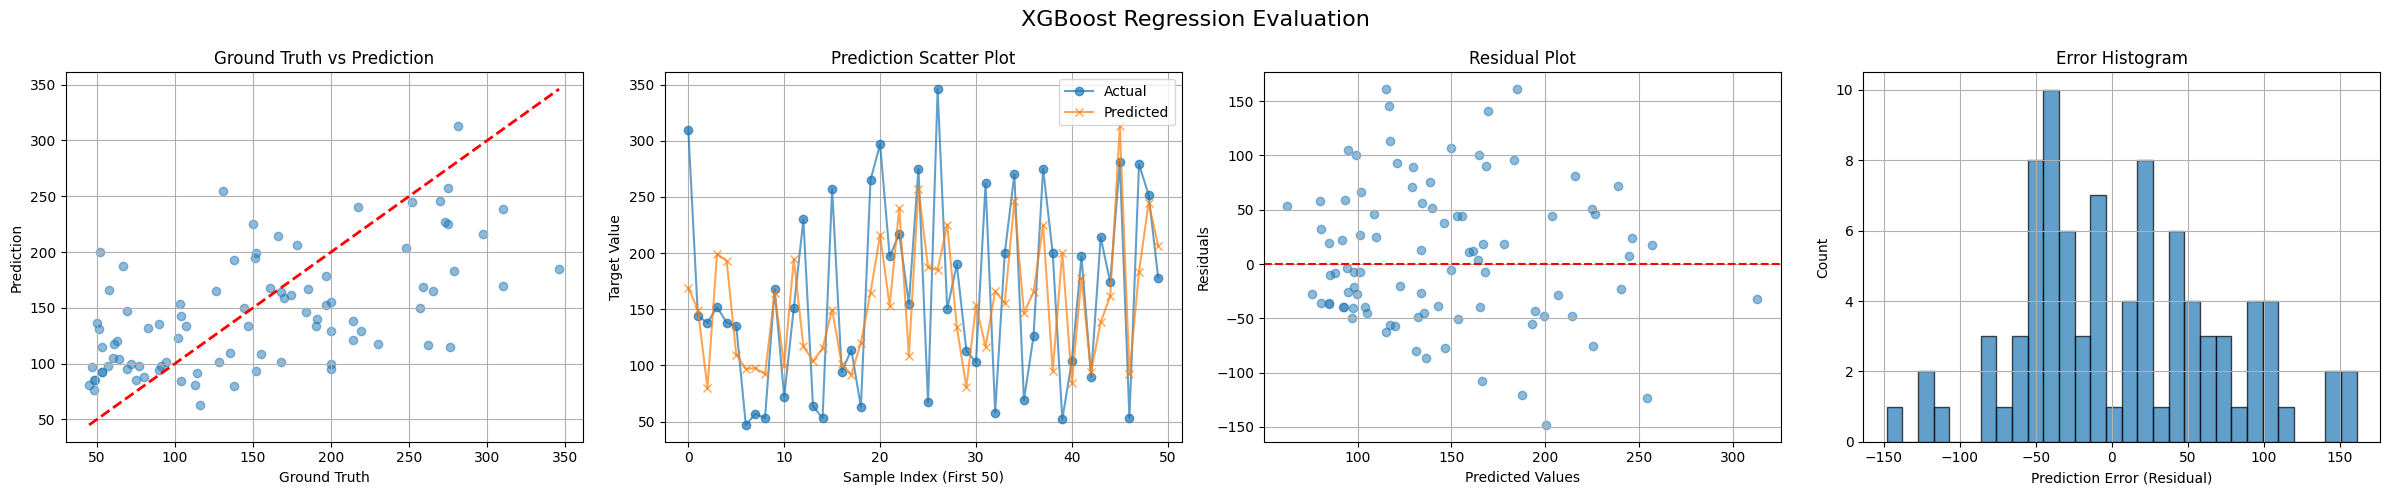

In [48]:
# Visualization for XGBoost Regression
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("XGBoost Regression Evaluation", fontsize=16)

# 1. Ground Truth vs Prediction
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].scatter(y_true, y_pred, alpha=0.5)
axes[0].set_xlabel("Ground Truth")
axes[0].set_ylabel("Prediction")
axes[0].set_title("Ground Truth vs Prediction")
axes[0].grid(True)

# 2. Prediction Scatter Plot (Index vs Value)
axes[1].plot(y_true[:50], label='Actual', marker='o', alpha=0.7)
axes[1].plot(y_pred[:50], label='Predicted', marker='x', alpha=0.7)
axes[1].set_xlabel("Sample Index (First 50)")
axes[1].set_ylabel("Target Value")
axes[1].set_title("Prediction Scatter Plot")
axes[1].legend()
axes[1].grid(True)

# 3. Residual Plot
residuals = y_true - y_pred
axes[2].scatter(y_pred, residuals, alpha=0.5)
axes[2].axhline(0, color='r', linestyle='--')
axes[2].set_xlabel("Predicted Values")
axes[2].set_ylabel("Residuals")
axes[2].set_title("Residual Plot")
axes[2].grid(True)

# 4. Error Histogram
axes[3].hist(residuals, bins=30, edgecolor='k', alpha=0.7)
axes[3].set_xlabel("Prediction Error (Residual)")
axes[3].set_ylabel("Count")
axes[3].set_title("Error Histogram")
axes[3].grid(True)

plt.tight_layout()
plt.show()


# Final Comparison

Comparing the performance of all trained models.


In [49]:
# Create DataFrame
df_results = pd.DataFrame(results).T
display(df_results)


,MSE,RMSE,MAE,R² Score,Training Time,Prediction Time
Linear Regression,3352.859863,57.903885,47.418671,0.478460,0.720636,0.000984
Polynomial Regression,3292.583252,57.381035,47.259029,0.487836,0.032297,0.001990
SGD Regression,3255.307861,57.055305,46.889450,0.493634,9.684429,0.000457
Decision Tree Regression,5719.485840,75.627281,60.873383,0.110329,2.046886,0.015260
Random Forest Regression,4199.521484,64.803719,52.717747,0.346761,44.089436,0.151093
KNN Regression,4282.019043,65.437141,51.251678,0.333928,0.000584,0.178064
Support Vector Regression,26613.181641,163.135468,142.071854,-3.139704,0.963211,0.000405
Neural Network Regression,3833.589844,61.915989,47.969364,0.403682,1.225493,0.001524
XGBoost Regression,4317.021484,65.704048,53.601120,0.328484,24.143054,0.097838


In [50]:
# Rank models by R² Score (Descending)
df_ranked = df_results.sort_values(by="R² Score", ascending=False)
print("Models ranked by R² Score:")
display(df_ranked[["R² Score"]])


Models ranked by R² Score:


,R² Score
SGD Regression,0.493634
Polynomial Regression,0.487836
Linear Regression,0.478460
Neural Network Regression,0.403682
Random Forest Regression,0.346761
KNN Regression,0.333928
XGBoost Regression,0.328484
Decision Tree Regression,0.110329
Support Vector Regression,-3.139704


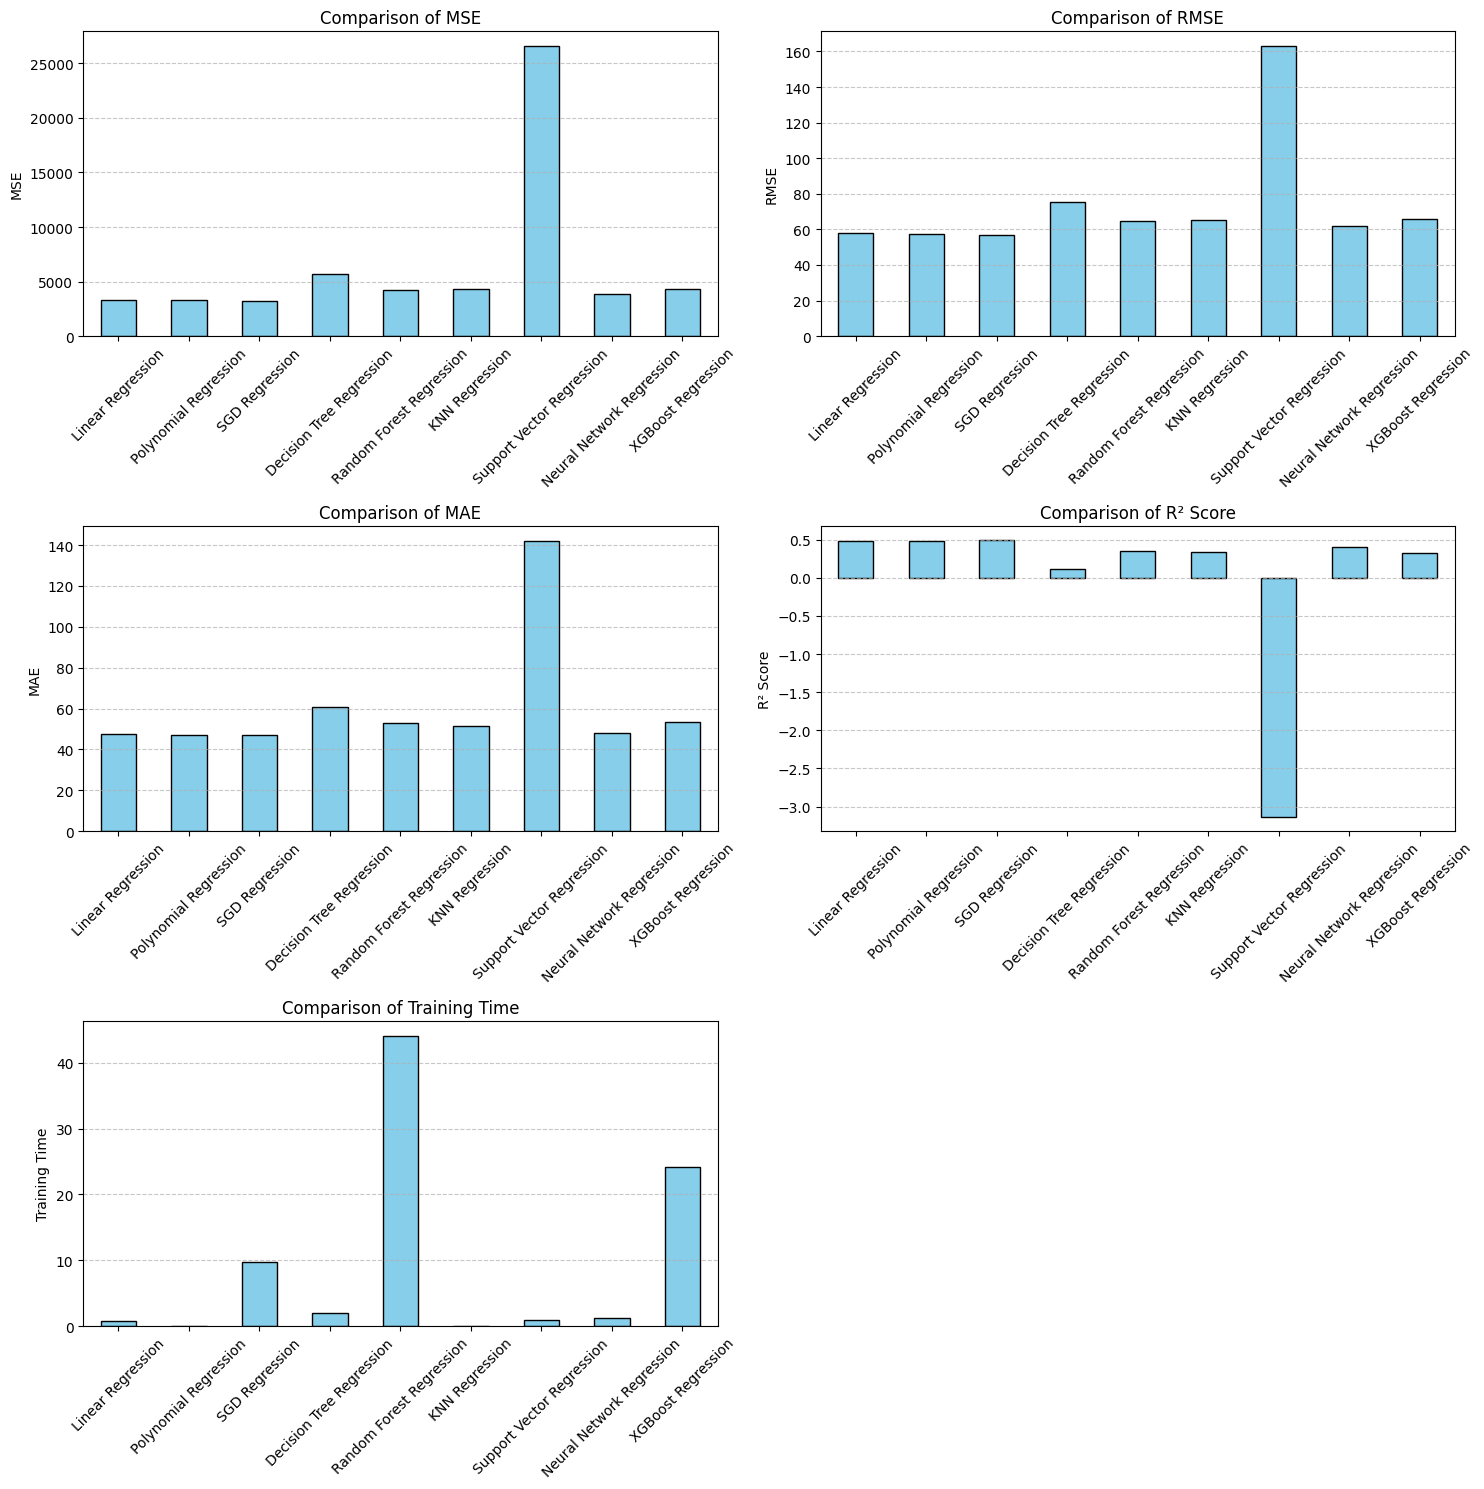

In [51]:
# Plot comparison charts
metrics = ["MSE", "RMSE", "MAE", "R² Score", "Training Time"]

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    df_results[metric].plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f"Comparison of {metric}")
    axes[i].set_ylabel(metric)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].tick_params(axis='x', rotation=45)

# Hide the empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()
